In [140]:
# Import required libraries
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import tifffile
from pathlib import Path
from ipywidgets import interact, IntSlider, FloatSlider, Dropdown
from joblib import Parallel, delayed
from tqdm.auto import tqdm
import pandas as pd
from scipy import stats
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Configuration and File Loading

In [ ]:
# Configuration
DATA_DIR = "/Users/lfbarba/GitHub/sdate/data/ct_files/file_6_extracted/"
N_JOBS = -1  # Use all available cores (-1), or specify number of cores

# Find all TIFF files in the directory
tiff_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.tif*")))

print(f"Found {len(tiff_files)} TIFF files")
if tiff_files:
    print(f"First file: {os.path.basename(tiff_files[0])}")
    print(f"Last file: {os.path.basename(tiff_files[-1])}")
else:
    print("No TIFF files found! Please check the directory path.")

Found 751 TIFF files
First file: MI04_020001.tif
Last file: MI04_020751.tif


## 2. Parallel Dynamic Range Analysis

Efficiently compute statistics for each frame using parallel processing.

In [113]:
def analyze_single_frame(filepath):
    """
    Analyze a single TIFF file and return comprehensive statistics.
    
    Returns:
        dict: Statistics including min, max, mean, std, percentiles, etc.
    """
    try:
        img = tifffile.imread(filepath)
        
        stats_dict = {
            'filename': os.path.basename(filepath),
            'min': np.min(img),
            'max': np.max(img),
            'mean': np.mean(img),
            'std': np.std(img),
            'median': np.median(img),
            'p01': np.percentile(img, 1),
            'p05': np.percentile(img, 5),
            'p95': np.percentile(img, 95),
            'p99': np.percentile(img, 99),
            'dtype': str(img.dtype),
            'shape': img.shape,
            'size_mb': img.nbytes / (1024**2)
        }
        
        # Calculate dynamic range metrics
        stats_dict['range'] = stats_dict['max'] - stats_dict['min']
        stats_dict['dynamic_range_db'] = 20 * np.log10(stats_dict['max'] / (stats_dict['min'] + 1e-10))
        
        # Calculate bit depth utilization
        if 'uint16' in stats_dict['dtype']:
            max_possible = 65535
        elif 'uint8' in stats_dict['dtype']:
            max_possible = 255
        else:
            max_possible = stats_dict['max']
        
        stats_dict['bit_utilization'] = (stats_dict['max'] / max_possible) * 100
        
        return stats_dict
    except Exception as e:
        print(f"Error processing {filepath}: {e}")
        return None

# Perform parallel analysis
print(f"Analyzing {len(tiff_files)} frames using {N_JOBS} cores...")
results = Parallel(n_jobs=N_JOBS)(
    delayed(analyze_single_frame)(f) for f in tqdm(tiff_files, desc="Analyzing frames")
)

# Filter out None results and create DataFrame
results = [r for r in results if r is not None]
df_stats = pd.DataFrame(results)
df_stats['frame_number'] = df_stats.index

print(f"\nAnalysis complete! Processed {len(df_stats)} frames successfully.")
print(f"\nDataset Overview:")
print(df_stats[['min', 'max', 'mean', 'std', 'range']].describe())

Analyzing 751 frames using -1 cores...


Analyzing frames:   0%|          | 0/751 [00:00<?, ?it/s]


Analysis complete! Processed 751 frames successfully.

Dataset Overview:
              min          max         mean         std        range
count  751.000000   751.000000   751.000000  751.000000   751.000000
mean   399.988016  2215.960053  1124.084407  274.973962  1815.972037
std    202.907430   618.598186   306.692086   71.706911   615.227689
min      0.000000    88.000000    14.642293    7.289497    88.000000
25%    312.000000  2018.000000  1121.666590  286.052325  1307.000000
50%    319.000000  2349.000000  1122.296137  296.217692  2035.000000
75%    696.000000  2580.500000  1383.340582  297.715607  2269.000000
max    728.000000  2928.000000  1403.155993  302.647414  2618.000000


## 3. Min/Max Values Over Time

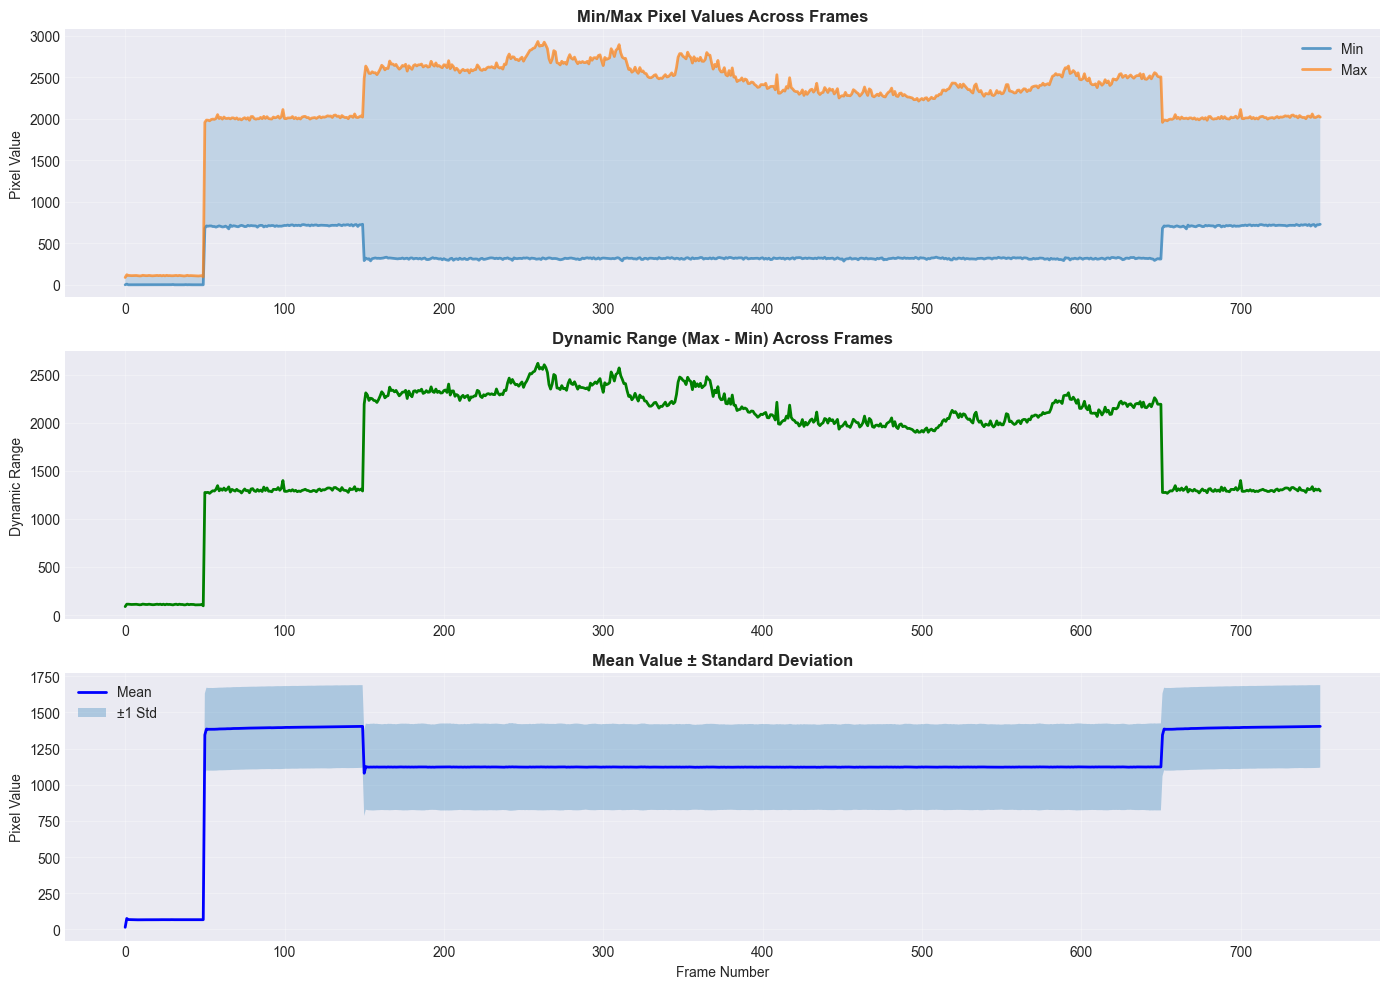

In [114]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Plot 1: Min and Max values
axes[0].plot(df_stats['frame_number'], df_stats['min'], label='Min', alpha=0.7, linewidth=2)
axes[0].plot(df_stats['frame_number'], df_stats['max'], label='Max', alpha=0.7, linewidth=2)
axes[0].fill_between(df_stats['frame_number'], df_stats['min'], df_stats['max'], alpha=0.2)
axes[0].set_ylabel('Pixel Value')
axes[0].set_title('Min/Max Pixel Values Across Frames', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Dynamic range (max - min)
axes[1].plot(df_stats['frame_number'], df_stats['range'], color='green', linewidth=2)
axes[1].set_ylabel('Dynamic Range')
axes[1].set_title('Dynamic Range (Max - Min) Across Frames', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Plot 3: Mean ± Std
axes[2].plot(df_stats['frame_number'], df_stats['mean'], label='Mean', color='blue', linewidth=2)
axes[2].fill_between(df_stats['frame_number'], 
                      df_stats['mean'] - df_stats['std'], 
                      df_stats['mean'] + df_stats['std'], 
                      alpha=0.3, label='±1 Std')
axes[2].set_xlabel('Frame Number')
axes[2].set_ylabel('Pixel Value')
axes[2].set_title('Mean Value ± Standard Deviation', fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Interactive Histogram Viewer

Use the slider to explore histograms of different frames.

In [ ]:
# Cache for loaded images to avoid reloading
image_cache = {}

def load_frame(frame_idx):
    """Load a frame with caching."""
    if frame_idx not in image_cache:
        image_cache[frame_idx] = tifffile.imread(tiff_files[frame_idx])
    return image_cache[frame_idx]

@interact(frame_idx=IntSlider(min=0, max=len(tiff_files)-1, step=1, value=0, description='Frame:'),
          bins=IntSlider(min=50, max=500, step=50, value=200, description='Bins:'),
          log_scale=Dropdown(options=[False, True], value=False, description='Log Scale:'))
def show_histogram(frame_idx, bins, log_scale):
    """Display interactive histogram for selected frame."""
    img = load_frame(frame_idx)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Display the image
    im = axes[0].imshow(img, cmap='gray')
    axes[0].set_title(f'Frame {frame_idx}: {os.path.basename(tiff_files[frame_idx])}', fontweight='bold')
    axes[0].axis('off')
    plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
    
    # Display the histogram
    axes[1].hist(img.flatten(), bins=bins, alpha=0.7, color='blue', edgecolor='black')
    axes[1].set_xlabel('Pixel Value')
    axes[1].set_ylabel('Frequency (log scale)' if log_scale else 'Frequency')
    axes[1].set_title(f'Histogram (Min: {df_stats.iloc[frame_idx]["min"]:.0f}, '
                     f'Max: {df_stats.iloc[frame_idx]["max"]:.0f}, '
                     f'Mean: {df_stats.iloc[frame_idx]["mean"]:.1f})', fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    if log_scale:
        axes[1].set_yscale('log')
    
    # Add vertical lines for statistics
    axes[1].axvline(df_stats.iloc[frame_idx]['mean'], color='red', linestyle='--', 
                   linewidth=2, label='Mean')
    axes[1].axvline(df_stats.iloc[frame_idx]['median'], color='green', linestyle='--', 
                   linewidth=2, label='Median')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\nFrame {frame_idx} Statistics:")
    print(f"  Shape: {img.shape}")
    print(f"  Data type: {img.dtype}")
    print(f"  Min: {df_stats.iloc[frame_idx]['min']:.2f}")
    print(f"  Max: {df_stats.iloc[frame_idx]['max']:.2f}")
    print(f"  Mean: {df_stats.iloc[frame_idx]['mean']:.2f}")
    print(f"  Std: {df_stats.iloc[frame_idx]['std']:.2f}")
    print(f"  Median: {df_stats.iloc[frame_idx]['median']:.2f}")
    print(f"  Dynamic Range (dB): {df_stats.iloc[frame_idx]['dynamic_range_db']:.2f}")
    print(f"  Bit Utilization: {df_stats.iloc[frame_idx]['bit_utilization']:.2f}%")

interactive(children=(IntSlider(value=0, description='Frame:', max=750), IntSlider(value=200, description='Bin…

## 5. Percentile Analysis

Visualize how different percentiles evolve over time.

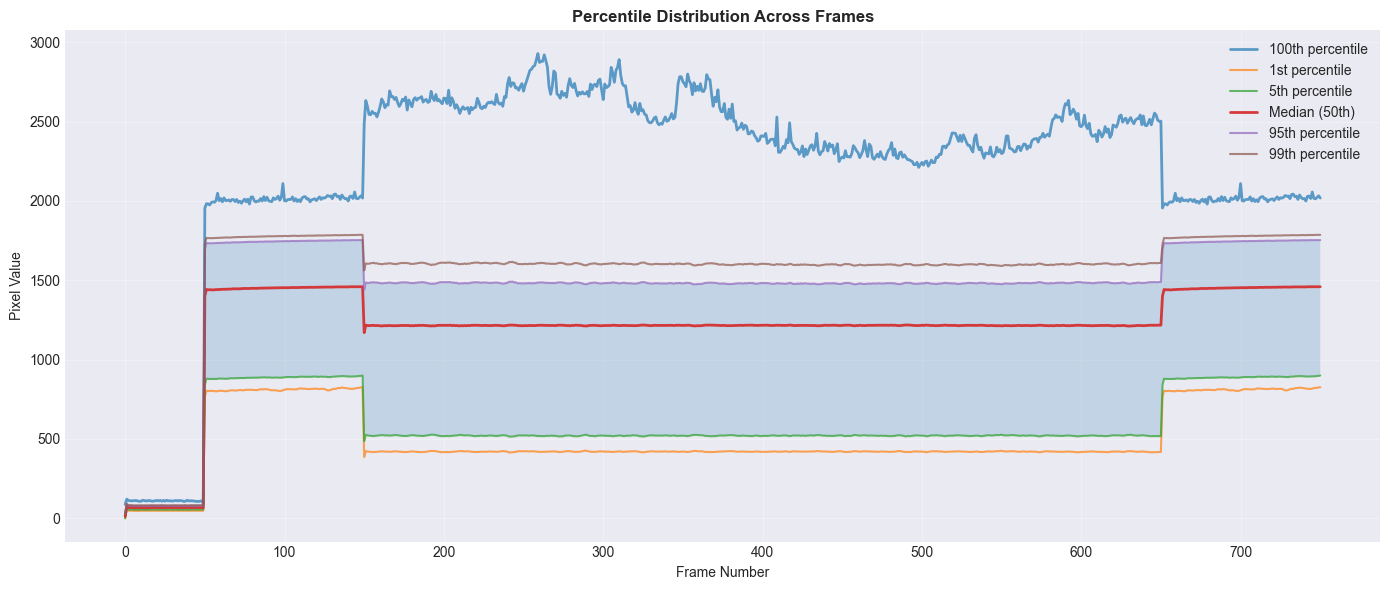

In [116]:
fig, ax = plt.subplots(figsize=(14, 6))

# Plot percentiles
ax.plot(df_stats['frame_number'], df_stats['max'], label='100th percentile', alpha=0.7, linewidth=2)
ax.plot(df_stats['frame_number'], df_stats['p01'], label='1st percentile', alpha=0.7)
ax.plot(df_stats['frame_number'], df_stats['p05'], label='5th percentile', alpha=0.7)
ax.plot(df_stats['frame_number'], df_stats['median'], label='Median (50th)', alpha=0.9, linewidth=2)
ax.plot(df_stats['frame_number'], df_stats['p95'], label='95th percentile', alpha=0.7)
ax.plot(df_stats['frame_number'], df_stats['p99'], label='99th percentile', alpha=0.7)


# Fill between percentiles
ax.fill_between(df_stats['frame_number'], df_stats['p05'], df_stats['p95'], alpha=0.2)

ax.set_xlabel('Frame Number')
ax.set_ylabel('Pixel Value')
ax.set_title('Percentile Distribution Across Frames', fontsize=12, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Bit Depth Utilization Analysis

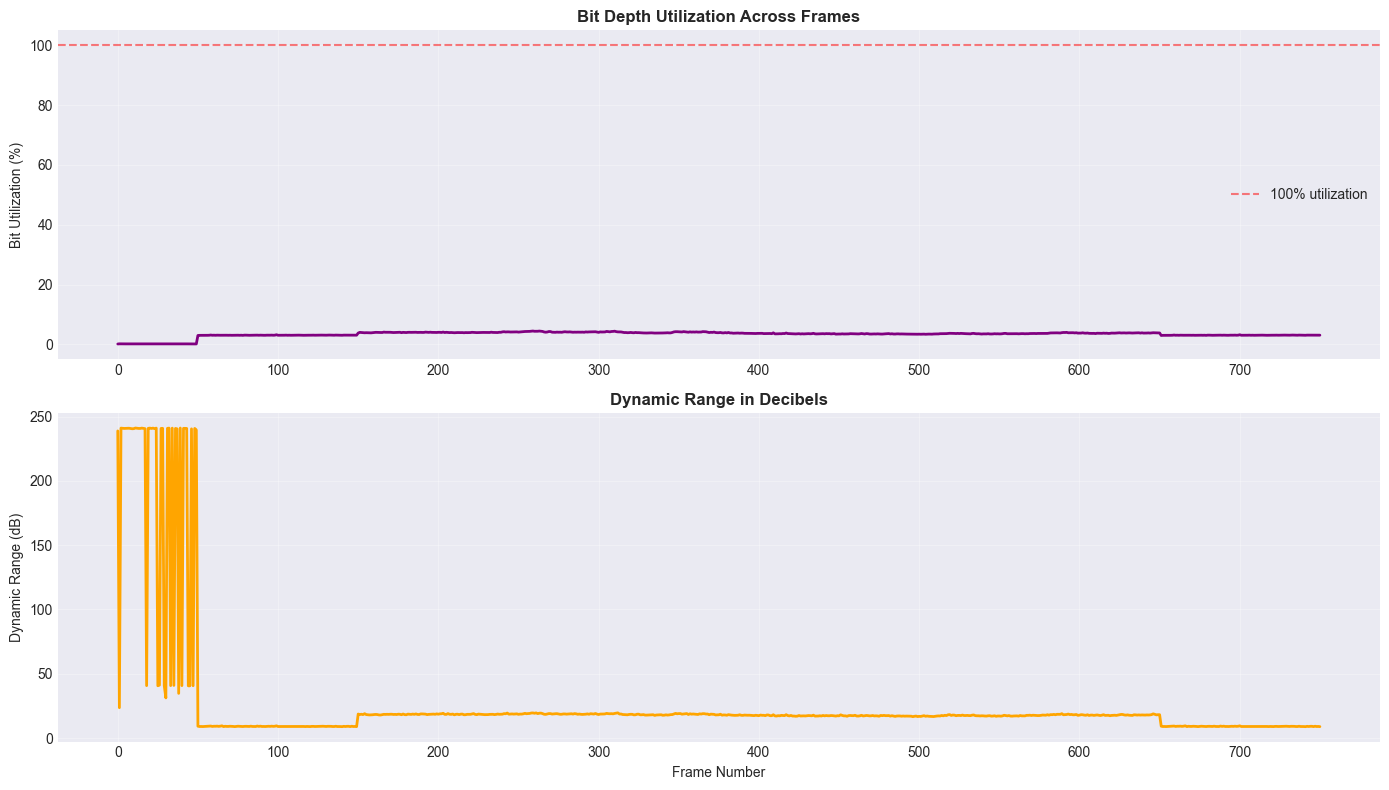


Bit Utilization Statistics:
  Mean: 3.38%
  Min: 0.13%
  Max: 4.47%

Dynamic Range Statistics (dB):
  Mean: 26.93 dB
  Min: 8.83 dB
  Max: 241.14 dB


In [117]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Bit utilization over time
axes[0].plot(df_stats['frame_number'], df_stats['bit_utilization'], linewidth=2, color='purple')
axes[0].axhline(y=100, color='red', linestyle='--', label='100% utilization', alpha=0.5)
axes[0].set_ylabel('Bit Utilization (%)')
axes[0].set_title('Bit Depth Utilization Across Frames', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Dynamic range in dB
axes[1].plot(df_stats['frame_number'], df_stats['dynamic_range_db'], linewidth=2, color='orange')
axes[1].set_xlabel('Frame Number')
axes[1].set_ylabel('Dynamic Range (dB)')
axes[1].set_title('Dynamic Range in Decibels', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nBit Utilization Statistics:")
print(f"  Mean: {df_stats['bit_utilization'].mean():.2f}%")
print(f"  Min: {df_stats['bit_utilization'].min():.2f}%")
print(f"  Max: {df_stats['bit_utilization'].max():.2f}%")
print(f"\nDynamic Range Statistics (dB):")
print(f"  Mean: {df_stats['dynamic_range_db'].mean():.2f} dB")
print(f"  Min: {df_stats['dynamic_range_db'].min():.2f} dB")
print(f"  Max: {df_stats['dynamic_range_db'].max():.2f} dB")

## 7. Temporal Variation Analysis

Analyze how much the frames change over time.

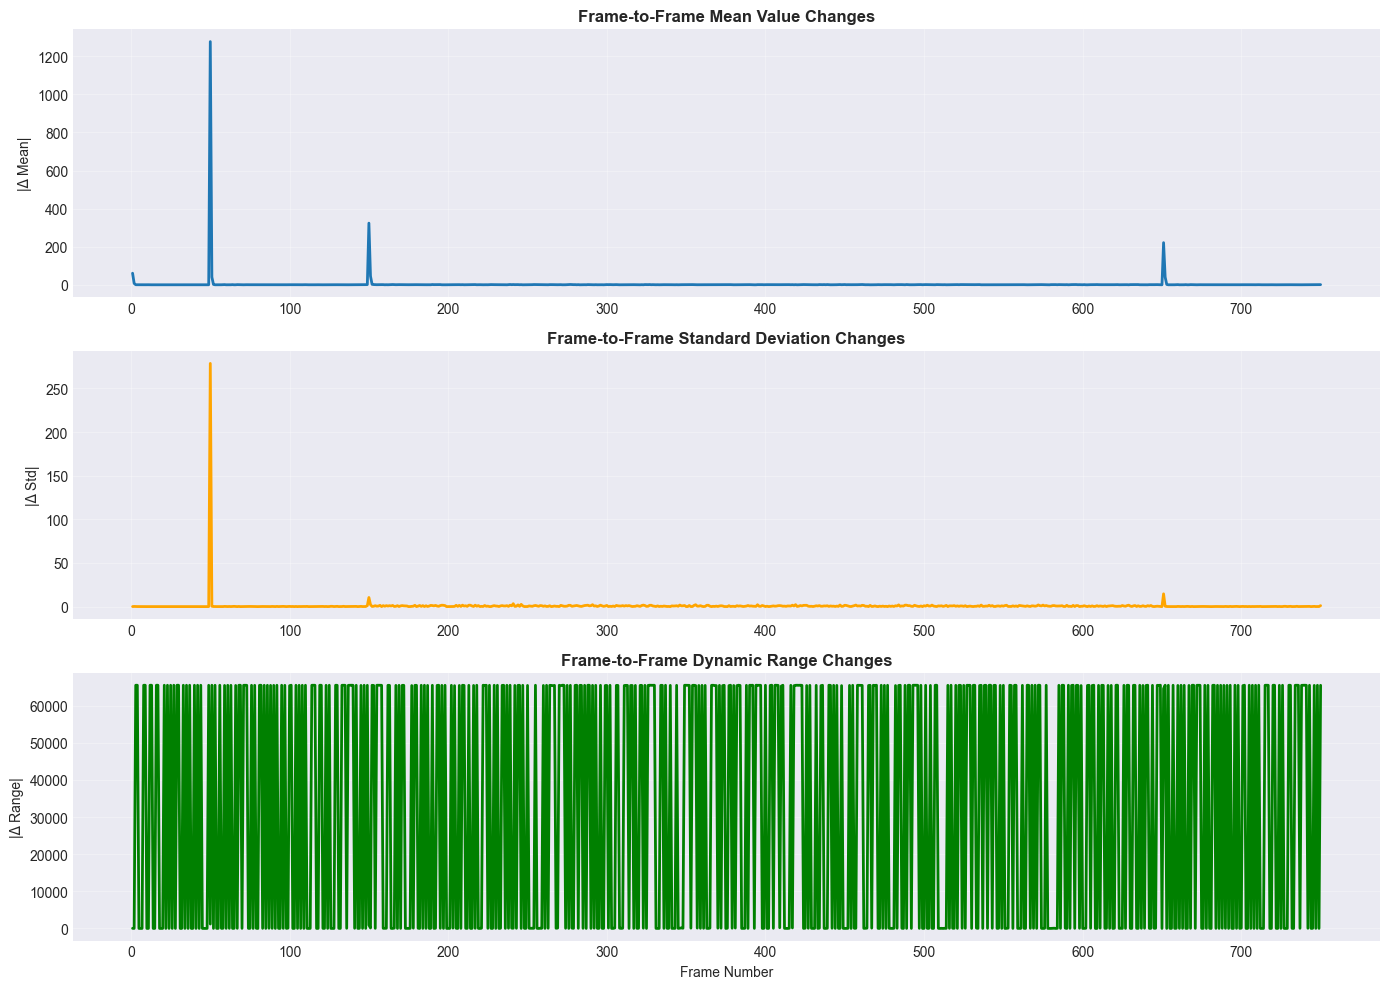


Frames with Largest Changes:

Top 5 frames with largest mean changes:
     frame_number    mean_diff         mean
50             50  1277.298755  1344.385904
150           150   323.805263  1079.350730
651           651   221.256069  1344.385904
1               1    60.817666    75.459959
151           151    45.427053  1124.777782

Top 5 frames with largest range changes:
     frame_number  range_diff  range
4               4     65535.0    110
42             42     65535.0    110
51             51     65535.0   1274
101           101     65535.0   1286
330           330     65535.0   2172


In [118]:
# Calculate frame-to-frame differences
df_stats['mean_diff'] = df_stats['mean'].diff().abs()
df_stats['std_diff'] = df_stats['std'].diff().abs()
df_stats['range_diff'] = df_stats['range'].diff().abs()

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Plot 1: Mean value changes
axes[0].plot(df_stats['frame_number'][1:], df_stats['mean_diff'][1:], linewidth=2)
axes[0].set_ylabel('|Δ Mean|')
axes[0].set_title('Frame-to-Frame Mean Value Changes', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot 2: Std changes
axes[1].plot(df_stats['frame_number'][1:], df_stats['std_diff'][1:], 
            linewidth=2, color='orange')
axes[1].set_ylabel('|Δ Std|')
axes[1].set_title('Frame-to-Frame Standard Deviation Changes', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Plot 3: Range changes
axes[2].plot(df_stats['frame_number'][1:], df_stats['range_diff'][1:], 
            linewidth=2, color='green')
axes[2].set_xlabel('Frame Number')
axes[2].set_ylabel('|Δ Range|')
axes[2].set_title('Frame-to-Frame Dynamic Range Changes', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Identify frames with largest changes
print("\nFrames with Largest Changes:")
print("\nTop 5 frames with largest mean changes:")
print(df_stats.nlargest(5, 'mean_diff')[['frame_number', 'mean_diff', 'mean']])
print("\nTop 5 frames with largest range changes:")
print(df_stats.nlargest(5, 'range_diff')[['frame_number', 'range_diff', 'range']])

## 8. Correlation Heatmap

Explore correlations between different statistics.

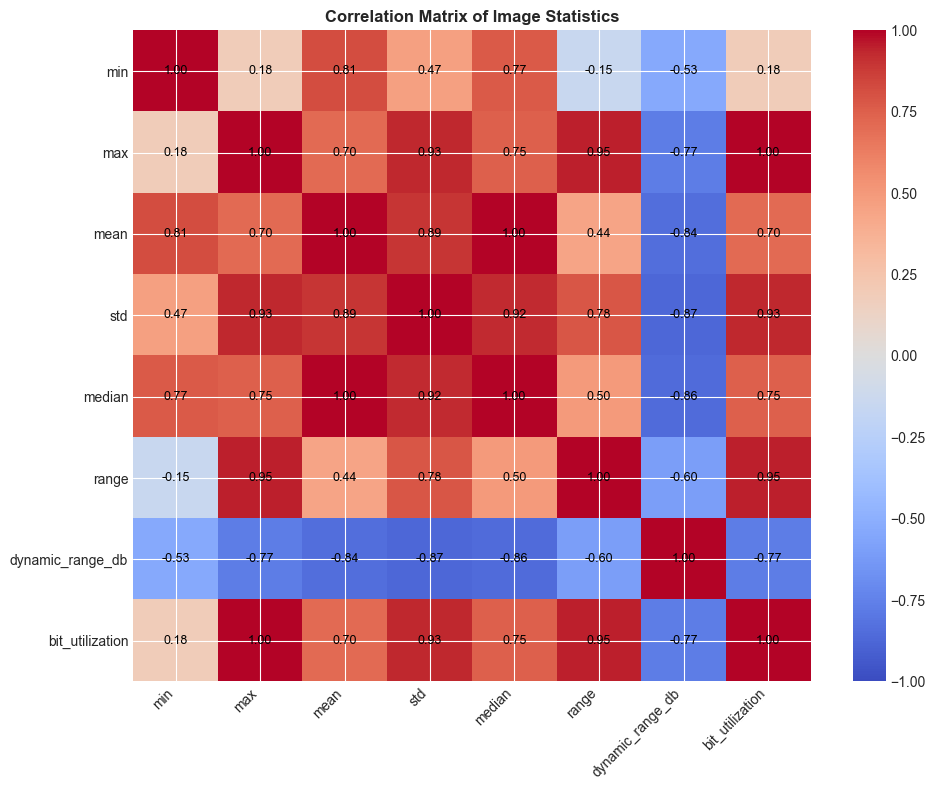

In [119]:
# Select numerical columns for correlation
corr_cols = ['min', 'max', 'mean', 'std', 'median', 'range', 'dynamic_range_db', 'bit_utilization']
corr_matrix = df_stats[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)

# Set ticks and labels
ax.set_xticks(np.arange(len(corr_cols)))
ax.set_yticks(np.arange(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='right')
ax.set_yticklabels(corr_cols)

# Add correlation values
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                      ha='center', va='center', color='black', fontsize=9)

ax.set_title('Correlation Matrix of Image Statistics', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 9. Advanced: 2D Histogram (Value vs. Time)

Visualize how pixel value distributions change over time.

In [120]:
# Create 2D histogram showing value distribution evolution
import torch


@interact(sample_frames=IntSlider(min=10, max=min(100, len(tiff_files)), 
                                  step=10, value=50, description='Sample Size:'),
          value_bins=IntSlider(min=50, max=200, step=50, value=100, description='Value Bins:'))
def show_2d_histogram(sample_frames, value_bins):
    """Display 2D histogram of pixel values over time."""
    # Sample frames evenly
    frame_indices = np.linspace(0, len(tiff_files)-1, sample_frames, dtype=int)
    
    # Determine value range
    global_min = df_stats['min'].min()
    global_max = df_stats['max'].max()
    
    # Create bins
    value_edges = np.linspace(global_min, global_max, value_bins)
    hist_2d = np.zeros((value_bins-1, sample_frames))
    
    # Compute histograms for sampled frames
    print(f"Computing 2D histogram for {sample_frames} frames...")
    for i, idx in enumerate(tqdm(frame_indices, desc="Processing")):
        img = load_frame(idx)
        hist, _ = np.histogram(img.flatten(), bins=value_edges)
        hist_2d[:, i] = hist
    
    # Plot
    fig, ax = plt.subplots(figsize=(14, 8))
    im = ax.imshow(hist_2d, aspect='auto', cmap='viridis', 
                   extent=[0, sample_frames-1, global_min, global_max],
                   origin='lower', interpolation='bilinear')
    
    ax.plot(torch.arange(51), df_stats['p01'][::len(df_stats['frame_number'])//sample_frames], label='1st percentile', alpha=0.7)
    ax.plot(torch.arange(51), df_stats['p99'][::len(df_stats['frame_number'])//sample_frames], label='99th percentile', alpha=0.7)
    
    ax.set_xlabel('Frame Index (sampled)', fontsize=12)
    ax.set_ylabel('Pixel Value', fontsize=12)
    ax.set_title('2D Histogram: Pixel Value Distribution Evolution', 
                fontsize=12, fontweight='bold')
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Frequency (log scale)', fontsize=10)
    
    # Use log scale for colormap
    im.set_norm(plt.cm.colors.LogNorm(vmin=hist_2d[hist_2d>0].min(), 
                                       vmax=hist_2d.max()))
    
    plt.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=50, description='Sample Size:', min=10, step=10), IntSlider(value=100, d…

## 10. Attenuation Correction Analysis

This section computes attenuation-corrected projections using the standard flat-field and dark-field correction:

$$\mu = -\ln\left(\frac{I - I_{\text{dark}}}{I_{\text{flat}} - I_{\text{dark}}}\right)$$

Where:
- $I$ is the raw projection
- $I_{\text{dark}}$ is the mean dark-field image  
- $I_{\text{flat}}$ is the mean flat-field image

The data is split according to the standard CT acquisition convention: first the darks, then the flats, then the projections.

In [121]:
# Import the tomography parameter loading function
import sys
from pathlib import Path

# Add project root to path for imports
SCRIPT_DIR = Path.cwd()
PROJECT_ROOT = SCRIPT_DIR.parent if SCRIPT_DIR.name == 'notebooks' else SCRIPT_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from sdate.pipelines.batch_compress_tomography import load_tomography_params

# Load tomography parameters (number of darks, flats, projections)
data_path = Path(DATA_DIR)
tomo_params = load_tomography_params(data_path)

num_darks = tomo_params['num_darks']
num_flats = tomo_params['num_flats']
num_projections = tomo_params['num_projections']

print(f"Tomography Parameters:")
print(f"  Number of darks: {num_darks}")
print(f"  Number of flats: {num_flats}")
print(f"  Number of projections: {num_projections}")
print(f"  Total files found: {len(tiff_files)}")

# Verify the counts match
expected_total = num_darks + num_flats + num_projections
if expected_total != len(tiff_files):
    print(f"\n⚠️ Warning: Expected {expected_total} files but found {len(tiff_files)}")
    print(f"   Using {min(num_projections, len(tiff_files) - num_darks - num_flats)} projections")

✅ Found parameters in MI04_02.log: {'num_darks': 50, 'num_flats': 100, 'num_projections': 501}
Tomography Parameters:
  Number of darks: 50
  Number of flats: 100
  Number of projections: 501
  Total files found: 751

⚠️ Warning: Expected 651 files but found 751
   Using 501 projections


In [122]:
# Compute mean dark and flat fields for attenuation correction
print("Computing mean dark and flat field images...")

# Load all dark frames and compute mean
dark_files = tiff_files[:num_darks]
dark_images = [tifffile.imread(f) for f in tqdm(dark_files, desc="Loading darks")]
dark_mean = np.mean(dark_images, axis=0).astype(np.float32)

# Load all flat frames and compute mean
flat_files = tiff_files[num_darks:num_darks + num_flats]
flat_images = [tifffile.imread(f) for f in tqdm(flat_files, desc="Loading flats")]
flat_mean = np.mean(flat_images, axis=0).astype(np.float32)

# Projection files start after darks and flats
projection_files = tiff_files[num_darks + num_flats:]

print(f"\n✅ Computed mean images:")
print(f"   Dark mean - shape: {dark_mean.shape}, min: {dark_mean.min():.2f}, max: {dark_mean.max():.2f}")
print(f"   Flat mean - shape: {flat_mean.shape}, min: {flat_mean.min():.2f}, max: {flat_mean.max():.2f}")
print(f"   Number of projection files: {len(projection_files)}")

Computing mean dark and flat field images...


Loading darks:   0%|          | 0/50 [00:00<?, ?it/s]

Loading flats:   0%|          | 0/100 [00:00<?, ?it/s]


✅ Computed mean images:
   Dark mean - shape: (1900, 1008), min: 0.62, max: 107.48
   Flat mean - shape: (1900, 1008), min: 718.35, max: 2003.98
   Number of projection files: 601


In [134]:
# Cache for attenuation-corrected images
attenuation_cache = {}

def compute_attenuation(projection: np.ndarray, dark_mean: np.ndarray, flat_mean: np.ndarray, 
                        epsilon: float = 1e-6) -> np.ndarray:
    """
    Compute attenuation from a projection using flat-field and dark-field correction.
    
    Attenuation formula: μ = -ln((I - dark) / (flat - dark))
    
    Parameters:
    -----------
    projection : ndarray
        Raw projection image
    dark_mean : ndarray
        Mean dark-field image
    flat_mean : ndarray
        Mean flat-field image
    epsilon : float
        Small value to avoid division by zero and log of zero
        
    Returns:
    --------
    attenuation : ndarray
        Attenuation-corrected image
    """
    # Compute the denominator (flat - dark)
    denominator = flat_mean - dark_mean
    # Avoid division by zero
    denominator = np.maximum(denominator, epsilon)
    
    # Compute the normalized transmission
    transmission = (projection.astype(np.float32) - dark_mean) / denominator
    
    # Clip transmission to avoid log of zero or negative values
    transmission = np.clip(transmission, epsilon, None)
    
    # Compute attenuation (Beer-Lambert law)
    attenuation = -np.log(transmission)
    
    return attenuation

def load_attenuation_frame(frame_idx: int) -> np.ndarray:
    """Load a projection frame and compute its attenuation with caching."""
    if frame_idx not in attenuation_cache:
        projection = tifffile.imread(projection_files[frame_idx])
        attenuation_cache[frame_idx] = compute_attenuation(projection, dark_mean, flat_mean)
    return attenuation_cache[frame_idx]

# Test with first projection
test_attenuation = load_attenuation_frame(0)
print(f"Attenuation image - shape: {test_attenuation.shape}")
print(f"  Min: {test_attenuation.min():.4f}")
print(f"  Max: {test_attenuation.max():.4f}")
print(f"  Mean: {test_attenuation.mean():.4f}")
print(f"  Std: {test_attenuation.std():.4f}")

Attenuation image - shape: (1900, 1008)
  Min: -0.4882
  Max: 1.1715
  Mean: 0.3013
  Std: 0.2550


In [135]:
# Interactive Histogram for Attenuation-Corrected Projections

@interact(frame_idx=IntSlider(min=0, max=len(projection_files)-1, step=1, value=0, 
                               description='Projection:'),
          bins=IntSlider(min=50, max=500, step=50, value=200, description='Bins:'),
          log_scale=Dropdown(options=[False, True], value=False, description='Log Scale:'),
          clip_percentile=FloatSlider(min=0.0, max=5.0, step=0.5, value=1.0, 
                                       description='Clip %:'))
def show_attenuation_histogram(frame_idx, bins, log_scale, clip_percentile):
    """Display interactive histogram for attenuation-corrected projection."""
    attenuation = load_attenuation_frame(frame_idx)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Clip extreme values for better visualization
    if clip_percentile > 0:
        vmin = np.percentile(attenuation, clip_percentile)
        vmax = np.percentile(attenuation, 100 - clip_percentile)
    else:
        vmin, vmax = attenuation.min(), attenuation.max()
    
    # Display the attenuation image
    im = axes[0].imshow(attenuation, cmap='gray', vmin=vmin, vmax=vmax)
    axes[0].set_title(f'Attenuation - Projection {frame_idx}: {os.path.basename(projection_files[frame_idx])}', 
                      fontweight='bold')
    axes[0].axis('off')
    plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04, label='μ (attenuation)')
    
    # Display the histogram
    # Filter out inf/nan values for histogram
    valid_data = attenuation[np.isfinite(attenuation)]
    
    axes[1].hist(valid_data.flatten(), bins=bins, alpha=0.7, color='purple', edgecolor='black')
    axes[1].set_xlabel('Attenuation (μ)')
    axes[1].set_ylabel('Frequency (log scale)' if log_scale else 'Frequency')
    axes[1].set_title(f'Attenuation Histogram (Min: {valid_data.min():.3f}, '
                     f'Max: {valid_data.max():.3f}, '
                     f'Mean: {valid_data.mean():.3f})', fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    if log_scale:
        axes[1].set_yscale('log')
    
    # Add vertical lines for statistics
    mean_val = valid_data.mean()
    median_val = np.median(valid_data)
    axes[1].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean ({mean_val:.3f})')
    axes[1].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median ({median_val:.3f})')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\nAttenuation Statistics for Projection {frame_idx}:")
    print(f"  Shape: {attenuation.shape}")
    print(f"  Min: {valid_data.min():.4f}")
    print(f"  Max: {valid_data.max():.4f}")
    print(f"  Mean: {valid_data.mean():.4f}")
    print(f"  Std: {valid_data.std():.4f}")
    print(f"  Median: {np.median(valid_data):.4f}")
    print(f"  1st percentile: {np.percentile(valid_data, 1):.4f}")
    print(f"  99th percentile: {np.percentile(valid_data, 99):.4f}")
    
    # Count invalid pixels
    num_inf = np.sum(~np.isfinite(attenuation))
    if num_inf > 0:
        print(f"  ⚠️ Invalid pixels (inf/nan): {num_inf} ({100*num_inf/attenuation.size:.2f}%)")

interactive(children=(IntSlider(value=0, description='Projection:', max=600), IntSlider(value=200, description…

### Side-by-side Comparison: Raw vs Attenuation-Corrected

Compare the raw projection intensity with the attenuation-corrected image.

In [136]:
@interact(frame_idx=IntSlider(min=0, max=len(projection_files)-1, step=1, value=0, 
                               description='Projection:'),
          clip_percentile=FloatSlider(min=0.0, max=5.0, step=0.5, value=1.0, 
                                       description='Clip %:'))
def compare_raw_vs_attenuation(frame_idx, clip_percentile):
    """Compare raw projection with attenuation-corrected image."""
    # Load raw projection (adjust index to account for darks and flats)
    raw_idx = num_darks + num_flats + frame_idx
    raw_projection = tifffile.imread(tiff_files[raw_idx])
    
    # Get attenuation-corrected version
    attenuation = load_attenuation_frame(frame_idx)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Raw projection image
    im0 = axes[0, 0].imshow(raw_projection, cmap='gray')
    axes[0, 0].set_title(f'Raw Projection {frame_idx}', fontweight='bold')
    axes[0, 0].axis('off')
    plt.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04, label='Intensity')
    
    # Attenuation image
    if clip_percentile > 0:
        vmin = np.percentile(attenuation, clip_percentile)
        vmax = np.percentile(attenuation, 100 - clip_percentile)
    else:
        vmin, vmax = attenuation.min(), attenuation.max()
    
    im1 = axes[0, 1].imshow(attenuation, cmap='gray', vmin=vmin, vmax=vmax)
    axes[0, 1].set_title(f'Attenuation-Corrected (μ)', fontweight='bold')
    axes[0, 1].axis('off')
    plt.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04, label='μ')
    
    # Raw histogram
    axes[1, 0].hist(raw_projection.flatten(), bins=200, alpha=0.7, color='blue', edgecolor='black')
    axes[1, 0].set_xlabel('Pixel Intensity')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Raw Projection Histogram', fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].axvline(raw_projection.mean(), color='red', linestyle='--', linewidth=2, label='Mean')
    axes[1, 0].legend()
    
    # Attenuation histogram
    valid_attenuation = attenuation[np.isfinite(attenuation)]
    axes[1, 1].hist(valid_attenuation.flatten(), bins=200, alpha=0.7, color='purple', edgecolor='black')
    axes[1, 1].set_xlabel('Attenuation (μ)')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('Attenuation Histogram', fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].axvline(valid_attenuation.mean(), color='red', linestyle='--', linewidth=2, label='Mean')
    axes[1, 1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print comparison statistics
    print(f"\n{'='*60}")
    print(f"Comparison for Projection {frame_idx}")
    print(f"{'='*60}")
    print(f"\n{'Raw Projection':<30} {'Attenuation-Corrected':<30}")
    print(f"{'-'*60}")
    print(f"{'Min:':<10} {raw_projection.min():<20.2f} {valid_attenuation.min():<20.4f}")
    print(f"{'Max:':<10} {raw_projection.max():<20.2f} {valid_attenuation.max():<20.4f}")
    print(f"{'Mean:':<10} {raw_projection.mean():<20.2f} {valid_attenuation.mean():<20.4f}")
    print(f"{'Std:':<10} {raw_projection.std():<20.2f} {valid_attenuation.std():<20.4f}")

interactive(children=(IntSlider(value=0, description='Projection:', max=600), FloatSlider(value=1.0, descripti…

### Percentile Distribution Across Attenuation-Corrected Frames

Analyze how percentiles of the attenuation values evolve across all projections.

In [126]:
# Compute attenuation statistics for all projections
print(f"Computing attenuation statistics for {len(projection_files)} projections...")

attenuation_stats = []

for idx in tqdm(range(len(projection_files)), desc="Processing projections"):
    attenuation = load_attenuation_frame(idx)
    valid_data = attenuation[np.isfinite(attenuation)]
    
    stats_dict = {
        'frame_number': idx,
        'min': valid_data.min(),
        'max': valid_data.max(),
        'mean': valid_data.mean(),
        'std': valid_data.std(),
        'median': np.median(valid_data),
        'p01': np.percentile(valid_data, 1),
        'p05': np.percentile(valid_data, 5),
        'p95': np.percentile(valid_data, 95),
        'p99': np.percentile(valid_data, 99),
        'invalid_pixels': np.sum(~np.isfinite(attenuation))
    }
    attenuation_stats.append(stats_dict)

df_attenuation_stats = pd.DataFrame(attenuation_stats)

print(f"\n✅ Attenuation Statistics Computed!")
print(f"\nAttenuation Dataset Overview:")
print(df_attenuation_stats[['min', 'max', 'mean', 'std']].describe())

Computing attenuation statistics for 601 projections...


Processing projections:   0%|          | 0/601 [00:00<?, ?it/s]


✅ Attenuation Statistics Computed!

Attenuation Dataset Overview:
              min         max        mean         std
count  601.000000  601.000000  601.000000  601.000000
mean    -0.434259    0.877822    0.213245    0.204002
std      0.176829    0.362440    0.095373    0.086443
min     -0.657450    0.047732   -0.007483    0.010263
25%     -0.554138    1.016476    0.255090    0.239660
50%     -0.483411    1.032985    0.255567    0.241799
75%     -0.430370    1.048381    0.255938    0.243931
max      0.000000    1.171519    0.308798    0.250183


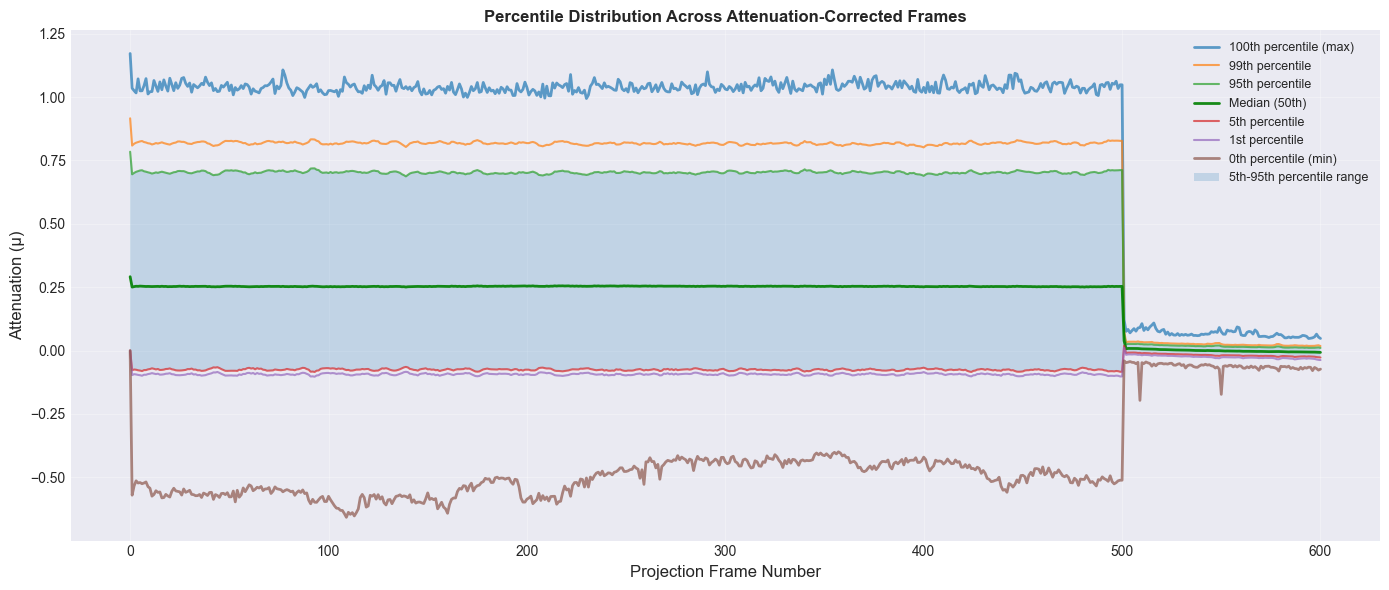


Attenuation Percentile Summary:
  Global min: -0.6574
  Global max: 1.1715
  Mean of medians: 0.2111
  Typical range (5th-95th): [-0.0657, 0.5889]


In [127]:
# Plot Percentile Distribution for Attenuation-Corrected Projections
fig, ax = plt.subplots(figsize=(14, 6))

# Plot percentiles
ax.plot(df_attenuation_stats['frame_number'], df_attenuation_stats['max'], 
        label='100th percentile (max)', alpha=0.7, linewidth=2)
ax.plot(df_attenuation_stats['frame_number'], df_attenuation_stats['p99'], 
        label='99th percentile', alpha=0.7)
ax.plot(df_attenuation_stats['frame_number'], df_attenuation_stats['p95'], 
        label='95th percentile', alpha=0.7)
ax.plot(df_attenuation_stats['frame_number'], df_attenuation_stats['median'], 
        label='Median (50th)', alpha=0.9, linewidth=2, color='green')
ax.plot(df_attenuation_stats['frame_number'], df_attenuation_stats['p05'], 
        label='5th percentile', alpha=0.7)
ax.plot(df_attenuation_stats['frame_number'], df_attenuation_stats['p01'], 
        label='1st percentile', alpha=0.7)
ax.plot(df_attenuation_stats['frame_number'], df_attenuation_stats['min'], 
        label='0th percentile (min)', alpha=0.7, linewidth=2)

# Fill between percentiles
ax.fill_between(df_attenuation_stats['frame_number'], 
                df_attenuation_stats['p05'], 
                df_attenuation_stats['p95'], 
                alpha=0.2, label='5th-95th percentile range')

ax.set_xlabel('Projection Frame Number', fontsize=12)
ax.set_ylabel('Attenuation (μ)', fontsize=12)
ax.set_title('Percentile Distribution Across Attenuation-Corrected Frames', 
             fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nAttenuation Percentile Summary:")
print(f"  Global min: {df_attenuation_stats['min'].min():.4f}")
print(f"  Global max: {df_attenuation_stats['max'].max():.4f}")
print(f"  Mean of medians: {df_attenuation_stats['median'].mean():.4f}")
print(f"  Typical range (5th-95th): [{df_attenuation_stats['p05'].mean():.4f}, {df_attenuation_stats['p95'].mean():.4f}]")

## 12. CDF-Based Histogram Mapping

This section implements a **CDF (Cumulative Distribution Function) mapping** that transforms pixel values to a uniform distribution in [0, 1]. 

The mapping is:
1. Compute the histogram of the image
2. Compute the CDF from the histogram
3. Map each pixel value to its corresponding CDF value

This transformation is **invertible**: given the stored CDF, we can map back from uniform [0, 1] to original values using the inverse CDF (quantile function).

**Key properties:**
- The mapped image has a (nearly) uniform histogram
- The mapping is monotonic and preserves ordering
- The CDF can be stored compactly as a lookup table for reconstruction

In [147]:
# Import CDF mapping functions from sdate.utils.normalization
from sdate.utils.normalization import (
    compute_cdf_mapping,
    apply_cdf_mapping,
    invert_cdf_mapping,
    save_cdf_mapping,
    load_cdf_mapping
)

print("✅ CDF mapping functions imported from sdate.utils.normalization:")
print("   - compute_cdf_mapping(image, num_bins)")
print("   - apply_cdf_mapping(image, mapping)")
print("   - invert_cdf_mapping(mapped_image, mapping)")
print("   - save_cdf_mapping(mapping, filepath)")
print("   - load_cdf_mapping(filepath)")

✅ CDF mapping functions imported from sdate.utils.normalization:
   - compute_cdf_mapping(image, num_bins)
   - apply_cdf_mapping(image, mapping)
   - invert_cdf_mapping(mapped_image, mapping)
   - save_cdf_mapping(mapping, filepath)
   - load_cdf_mapping(filepath)


In [149]:
# Interactive CDF Mapping Visualization

@interact(
    frame_idx=IntSlider(min=0, max=len(projection_files)-1, step=1, value=0, description='Frame:'),
    data_type=Dropdown(options=['Raw Intensity', 'Attenuation'], value='Attenuation', description='Data Type:'),
    num_bins=IntSlider(min=100, max=2000, step=100, value=500, description='Bins:'),
    log_hist=Dropdown(options=[False, True], value=True, description='Log Hist:')
)
def show_cdf_mapping(frame_idx, data_type, num_bins, log_hist):
    """Display interactive CDF mapping for selected frame."""
    
    # Load the appropriate data
    if data_type == 'Attenuation':
        image = load_attenuation_frame(frame_idx)
        value_label = 'Attenuation (μ)'
        title_prefix = 'Attenuation'
    else:
        # Load raw projection
        raw_idx = num_darks + num_flats + frame_idx
        image = tifffile.imread(tiff_files[raw_idx]).astype(np.float32)
        value_label = 'Pixel Intensity'
        title_prefix = 'Raw Intensity'
    
    # Compute CDF mapping
    mapping = compute_cdf_mapping(image, num_bins=num_bins)
    
    # Apply mapping
    mapped_image = apply_cdf_mapping(image, mapping)
    
    # Test inversion
    reconstructed = invert_cdf_mapping(mapped_image, mapping)
    
    # Filter valid data for metrics computation
    valid_data = image[np.isfinite(image)].flatten()
    
    # Compute reconstruction error and quality metrics
    valid_mask = np.isfinite(image) & np.isfinite(reconstructed)
    if valid_mask.any():
        reconstruction_error = np.abs(image[valid_mask] - reconstructed[valid_mask])
        max_error = reconstruction_error.max()
        mean_error = reconstruction_error.mean()
        
        # Compute PSNR and SSIM
        # For PSNR/SSIM, we need the full images with same shape
        # Replace invalid values with 0 for metric computation
        img_for_metrics = image.copy()
        rec_for_metrics = reconstructed.copy()
        img_for_metrics[~valid_mask] = 0
        rec_for_metrics[~valid_mask] = 0
        
        # Compute data range for metrics
        data_range = valid_data.max() - valid_data.min()
        
        # Compute PSNR (Peak Signal-to-Noise Ratio)
        psnr_value = psnr(img_for_metrics, rec_for_metrics, data_range=data_range)
        
        # Compute SSIM (Structural Similarity Index)
        ssim_value = ssim(img_for_metrics, rec_for_metrics, data_range=data_range)
    else:
        max_error = mean_error = psnr_value = ssim_value = np.nan
    
    # Create figure with 2x3 subplots
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # Row 1: CDF and Histograms
    # Plot 1: Original Histogram and CDF
    ax1 = axes[0, 0]
    ax1_twin = ax1.twinx()
    
    # Plot histogram
    ax1.hist(valid_data, bins=num_bins, alpha=0.6, color='blue', density=True, label='Histogram')
    if log_hist:
        ax1.set_yscale('log')
    ax1.set_xlabel(value_label, fontsize=10)
    ax1.set_ylabel('Density (Histogram)', fontsize=10, color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    
    # Plot CDF on twin axis
    ax1_twin.plot(mapping['bin_centers'], mapping['cdf'], 'r-', linewidth=2, label='CDF')
    ax1_twin.set_ylabel('CDF', fontsize=10, color='red')
    ax1_twin.tick_params(axis='y', labelcolor='red')
    ax1_twin.set_ylim(0, 1.05)
    
    ax1.set_title(f'Original {title_prefix} Distribution & CDF', fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: CDF Mapping Function (as a transfer function)
    ax2 = axes[0, 1]
    ax2.plot(mapping['bin_centers'], mapping['cdf'], 'b-', linewidth=2)
    ax2.fill_between(mapping['bin_centers'], 0, mapping['cdf'], alpha=0.3)
    ax2.set_xlabel(f'Input: {value_label}', fontsize=10)
    ax2.set_ylabel('Output: CDF Value [0, 1]', fontsize=10)
    ax2.set_title('CDF Transfer Function (Mapping)', fontweight='bold')
    ax2.set_ylim(0, 1.05)
    ax2.grid(True, alpha=0.3)
    
    # Add diagonal reference line
    x_range = mapping['bin_centers']
    x_normalized = (x_range - x_range.min()) / (x_range.max() - x_range.min())
    ax2.plot(x_range, x_normalized, 'k--', alpha=0.5, label='Linear (no mapping)')
    ax2.legend(loc='lower right')
    
    # Plot 3: Histogram After CDF Mapping (should be ~uniform)
    ax3 = axes[0, 2]
    valid_mapped = mapped_image[np.isfinite(mapped_image)].flatten()
    ax3.hist(valid_mapped, bins=50, alpha=0.7, color='green', edgecolor='black', density=True)
    ax3.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Uniform target')
    ax3.set_xlabel('CDF-Mapped Value [0, 1]', fontsize=10)
    ax3.set_ylabel('Density', fontsize=10)
    ax3.set_title('Histogram After CDF Mapping\n(Should be ~Uniform)', fontweight='bold')
    ax3.set_xlim(0, 1)
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Row 2: Images
    # Plot 4: Original Image
    ax4 = axes[1, 0]
    vmin, vmax = np.percentile(valid_data, [1, 99])
    im4 = ax4.imshow(image, cmap='gray', vmin=vmin, vmax=vmax)
    ax4.set_title(f'Original {title_prefix}', fontweight='bold')
    ax4.axis('off')
    plt.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04, label=value_label)
    
    # Plot 5: CDF-Mapped Image
    ax5 = axes[1, 1]
    im5 = ax5.imshow(mapped_image, cmap='gray', vmin=0, vmax=1)
    ax5.set_title('CDF-Mapped Image [0, 1]', fontweight='bold')
    ax5.axis('off')
    plt.colorbar(im5, ax=ax5, fraction=0.046, pad=0.04, label='CDF Value')
    
    # Plot 6: Reconstruction Error with Quality Metrics
    ax6 = axes[1, 2]
    error_image = np.abs(image - reconstructed)
    im6 = ax6.imshow(error_image, cmap='hot', vmin=0, vmax=np.nanpercentile(error_image, 99))
    ax6.set_title(f'Reconstruction Quality\nPSNR: {psnr_value:.2f} dB | SSIM: {ssim_value:.4f}\n(Max Error: {max_error:.6f})', 
                  fontweight='bold', fontsize=10)
    ax6.axis('off')
    plt.colorbar(im6, ax=ax6, fraction=0.046, pad=0.04, label='Absolute Error')
    
    plt.suptitle(f'CDF Mapping Analysis - Frame {frame_idx} ({data_type})', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\n{'='*70}")
    print(f"CDF Mapping Statistics for Frame {frame_idx} ({data_type})")
    print(f"{'='*70}")
    print(f"  Original value range: [{mapping['min_val']:.4f}, {mapping['max_val']:.4f}]")
    print(f"  Number of bins: {num_bins}")
    print(f"  Mapped value range: [{valid_mapped.min():.4f}, {valid_mapped.max():.4f}]")
    print(f"\n  Reconstruction Quality:")
    print(f"    PSNR: {psnr_value:.2f} dB")
    print(f"    SSIM: {ssim_value:.6f}")
    print(f"    Max error: {max_error:.6f}")
    print(f"    Mean error: {mean_error:.6f}")
    print(f"\n  CDF Mapping can be stored as:")
    print(f"    - bin_edges: {len(mapping['bin_edges'])} values")
    print(f"    - cdf: {len(mapping['cdf'])} values")
    print(f"    - Total storage: ~{(len(mapping['bin_edges']) + len(mapping['cdf'])) * 4 / 1024:.2f} KB (float32)")

interactive(children=(IntSlider(value=0, description='Frame:', max=600), Dropdown(description='Data Type:', in…

### Saving and Loading CDF Mappings

The CDF mapping can be saved to disk for later reconstruction. This enables compression pipelines to store the mapping alongside compressed data.

In [148]:
# Example: Test save and reload mapping for verification
# (save_cdf_mapping and load_cdf_mapping are imported from sdate.utils.normalization)

test_frame = load_attenuation_frame(0)
test_mapping = compute_cdf_mapping(test_frame, num_bins=500)

# Save to temporary file
temp_mapping_path = "/tmp/test_cdf_mapping.npz"
save_cdf_mapping(test_mapping, temp_mapping_path)
print(f"✅ CDF mapping saved to: {temp_mapping_path}")

# Reload and verify
reloaded_mapping = load_cdf_mapping(temp_mapping_path)
print(f"✅ CDF mapping loaded from: {temp_mapping_path}")

# Verify mapping works the same
original_mapped = apply_cdf_mapping(test_frame, test_mapping)
reloaded_mapped = apply_cdf_mapping(test_frame, reloaded_mapping)

diff = np.abs(original_mapped[np.isfinite(original_mapped)] - reloaded_mapped[np.isfinite(reloaded_mapped)])
print(f"\n📊 Verification: Max difference after save/load: {diff.max():.10f}")
print(f"   (Should be 0 or machine precision)")

# Clean up
import os
os.remove(temp_mapping_path)
print(f"🧹 Cleaned up temporary file")

✅ CDF mapping saved to: /tmp/test_cdf_mapping.npz
✅ CDF mapping loaded from: /tmp/test_cdf_mapping.npz

📊 Verification: Max difference after save/load: 0.0000000000
   (Should be 0 or machine precision)
🧹 Cleaned up temporary file
